# Analisis Spasial Curah Hujan CHIRPS Seluruh Indonesia
Notebook ini digunakan untuk melakukan analisis spasial 2D (*spatial mapping*) curah hujan CHIRPS di seluruh wilayah Indonesia (menggunakan batas wilayah `Indonesia.geojson`). Kompatibel untuk eksekusi lokal maupun di platform Kaggle.

In [1]:
import os
import glob
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="white")
plt.rcParams['font.sans-serif'] = "DejaVu Sans"
plt.rcParams['font.family'] = "sans-serif"

## 1. Auto-Detect Path Dataset & Deteksi Lingkungan (Kaggle / Lokal)
Mencari lokasi ketersediaan file NetCDF (`.nc`) CHIRPS.

In [2]:
# Tentukan lokasi direktori data CHIRPS
possible_paths = [
    "/kaggle/input/datasets/jerismeteo/chirps-kebumen/data/CHIRPS/",
    "data/chirps",
    "data/CHIRPS"
]

data_dir = None
for p in possible_paths:
    if os.path.exists(p):
        data_dir = p
        break

if data_dir:
    print(f"✅ Menggunakan direktori CHIRPS: {data_dir}")
    nc_files = sorted(glob.glob(os.path.join(data_dir, "**/*.nc"), recursive=True))
    print(f"Total file NetCDF ditemukan: {len(nc_files)}")
else:
    raise FileNotFoundError("❌ Folder data CHIRPS tidak ditemukan!")

✅ Menggunakan direktori CHIRPS: /kaggle/input/datasets/jerismeteo/chirps-kebumen/data/CHIRPS/
Total file NetCDF ditemukan: 13330


## 2. Memuat Multi-File NetCDF & Vector Boundary Indonesia
Memuat dataset spasial CHIRPS menggunakan `xarray.open_mfdataset` dan memuat peta vektor `Indonesia.geojson`.

In [3]:
# Load dataset CHIRPS
ds = xr.open_mfdataset(nc_files, combine='by_coords')
print("--- Struktur Data CHIRPS ---")
print(ds)

# Load GeoJSON Indonesia
geojson_path = "Indonesia.geojson"
if os.path.exists(geojson_path):
    gdf_indo = gpd.read_file(geojson_path)
    print(f"\n✅ Berhasil memuat {geojson_path}")
else:
    gdf_indo = None
    print("⚠️ File Indonesia.geojson tidak ditemukan di direktori utama.")

/tmp/ipykernel_16/1265146336.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(nc_files, combine='by_coords')


--- Struktur Data CHIRPS ---
<xarray.Dataset> Size: 17GB
Dimensions:        (time: 13330, y: 341, x: 921)
Coordinates:
  * time           (time) datetime64[ns] 107kB 1990-01-01 ... 2026-06-30
  * y              (y) float64 3kB 6.025 5.975 5.925 ... -10.88 -10.93 -10.98
  * x              (x) float64 7kB 94.98 95.03 95.08 95.13 ... 140.9 140.9 141.0
Data variables:
    spatial_ref    (time) int64 107kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    precipitation  (time, y, x) float32 17GB dask.array<chunksize=(1, 341, 921), meta=np.ndarray>
⚠️ File Indonesia.geojson tidak ditemukan di direktori utama.


## 3. Peta Spasial Akumulasi Total & Rata-rata Harian
Memetakan total akumulasi volume hujan (mm) dan intensitas harian rata-rata (mm/hari) di seluruh piksel grid Indonesia.

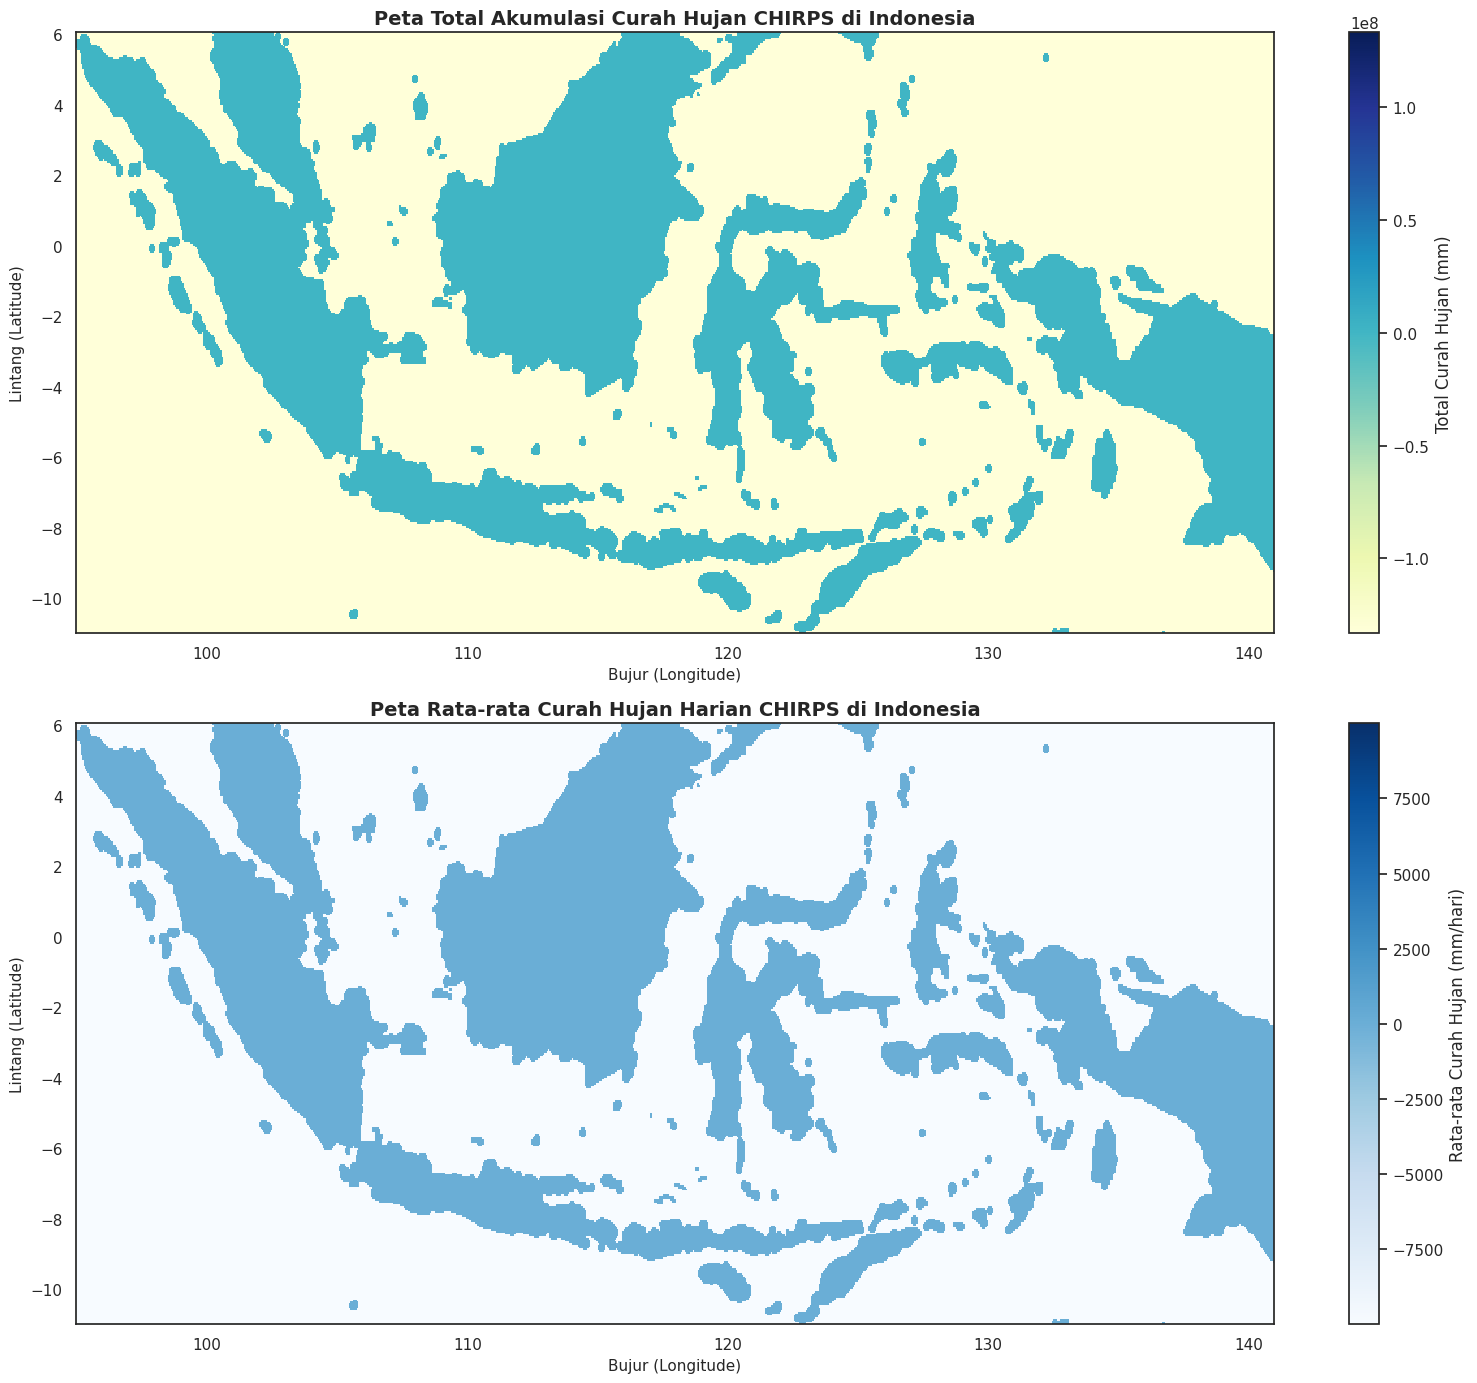

In [4]:
# Hitung akumulasi total dan rata-rata spasial
spatial_total = ds['precipitation'].sum(dim='time')
spatial_mean = ds['precipitation'].mean(dim='time')

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# Peta Total Akumulasi
spatial_total.plot(ax=axes[0], cmap='YlGnBu', cbar_kwargs={'label': 'Total Curah Hujan (mm)'})
if gdf_indo is not None:
    gdf_indo.boundary.plot(ax=axes[0], color='black', linewidth=0.6, alpha=0.7)
axes[0].set_title("Peta Total Akumulasi Curah Hujan CHIRPS di Indonesia", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Bujur (Longitude)", fontsize=11)
axes[0].set_ylabel("Lintang (Latitude)", fontsize=11)

# Peta Rata-rata Harian
spatial_mean.plot(ax=axes[1], cmap='Blues', cbar_kwargs={'label': 'Rata-rata Curah Hujan (mm/hari)'})
if gdf_indo is not None:
    gdf_indo.boundary.plot(ax=axes[1], color='black', linewidth=0.6, alpha=0.7)
axes[1].set_title("Peta Rata-rata Curah Hujan Harian CHIRPS di Indonesia", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Bujur (Longitude)", fontsize=11)
axes[1].set_ylabel("Lintang (Latitude)", fontsize=11)

plt.tight_layout()
plt.show()

## 4. Analisis Musim Spasial (Musim Hujan DJF vs Musim Kemarau JJA)
Perbandingan kontras sebaran spasial hujan antara Musim Barat (DJF: Des-Jan-Feb) dan Musim Timur (JJA: Jun-Jul-Agu).

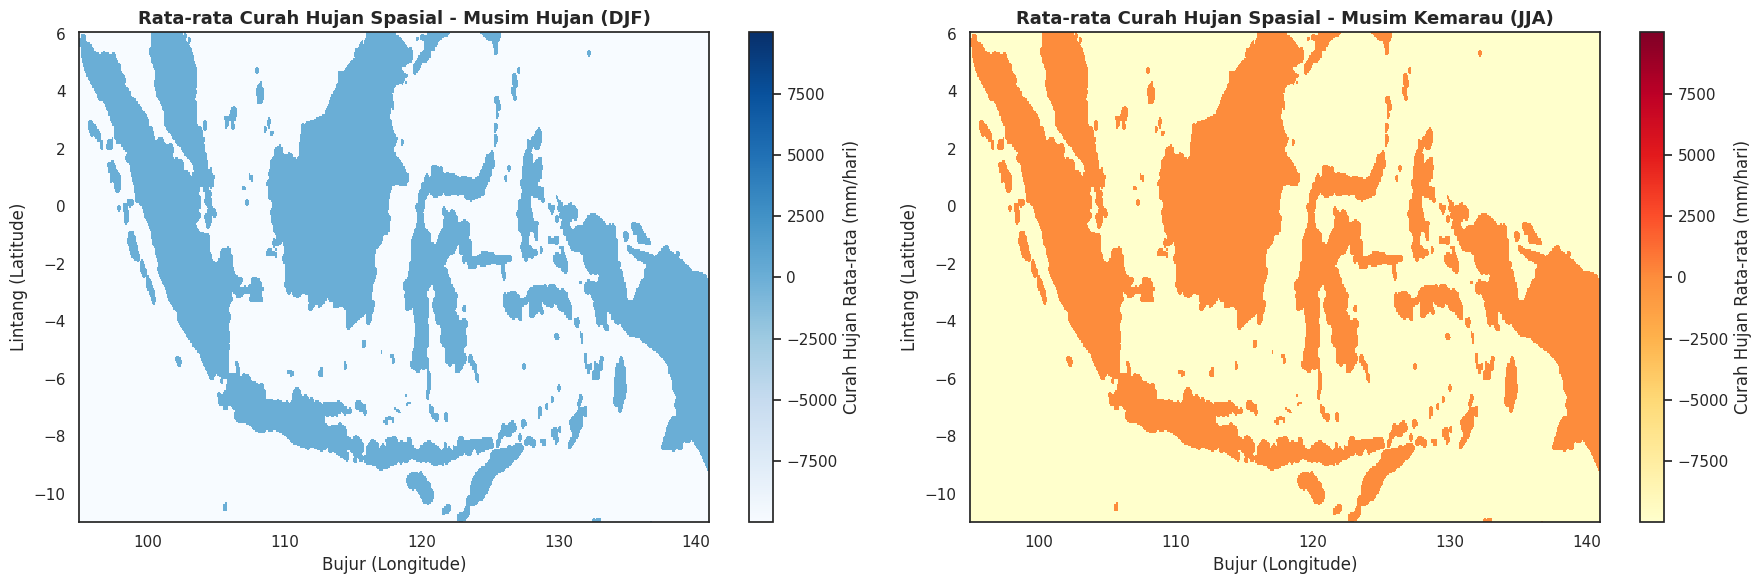

In [5]:
# Filter Musim Hujan (DJF) & Musim Kemarau (JJA)
ds_djf = ds.sel(time=ds.time.dt.month.isin([12, 1, 2]))['precipitation'].mean(dim='time')
ds_jja = ds.sel(time=ds.time.dt.month.isin([6, 7, 8]))['precipitation'].mean(dim='time')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Musim Hujan (DJF)
ds_djf.plot(ax=axes[0], cmap='Blues', cbar_kwargs={'label': 'Curah Hujan Rata-rata (mm/hari)'})
if gdf_indo is not None:
    gdf_indo.boundary.plot(ax=axes[0], color='crimson', linewidth=0.6)
axes[0].set_title("Rata-rata Curah Hujan Spasial - Musim Hujan (DJF)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Bujur (Longitude)")
axes[0].set_ylabel("Lintang (Latitude)")

# Musim Kemarau (JJA)
ds_jja.plot(ax=axes[1], cmap='YlOrRd', cbar_kwargs={'label': 'Curah Hujan Rata-rata (mm/hari)'})
if gdf_indo is not None:
    gdf_indo.boundary.plot(ax=axes[1], color='navy', linewidth=0.6)
axes[1].set_title("Rata-rata Curah Hujan Spasial - Musim Kemarau (JJA)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Bujur (Longitude)")
axes[1].set_ylabel("Lintang (Latitude)")

plt.tight_layout()
plt.show()

## 5. Grid Klimatologi Spasial Bulanan (12-Subplot Grid)
Memetakan pola sebaran hujan spasial dari bulan Januari hingga Desember untuk melihat pergerakan Monsun.

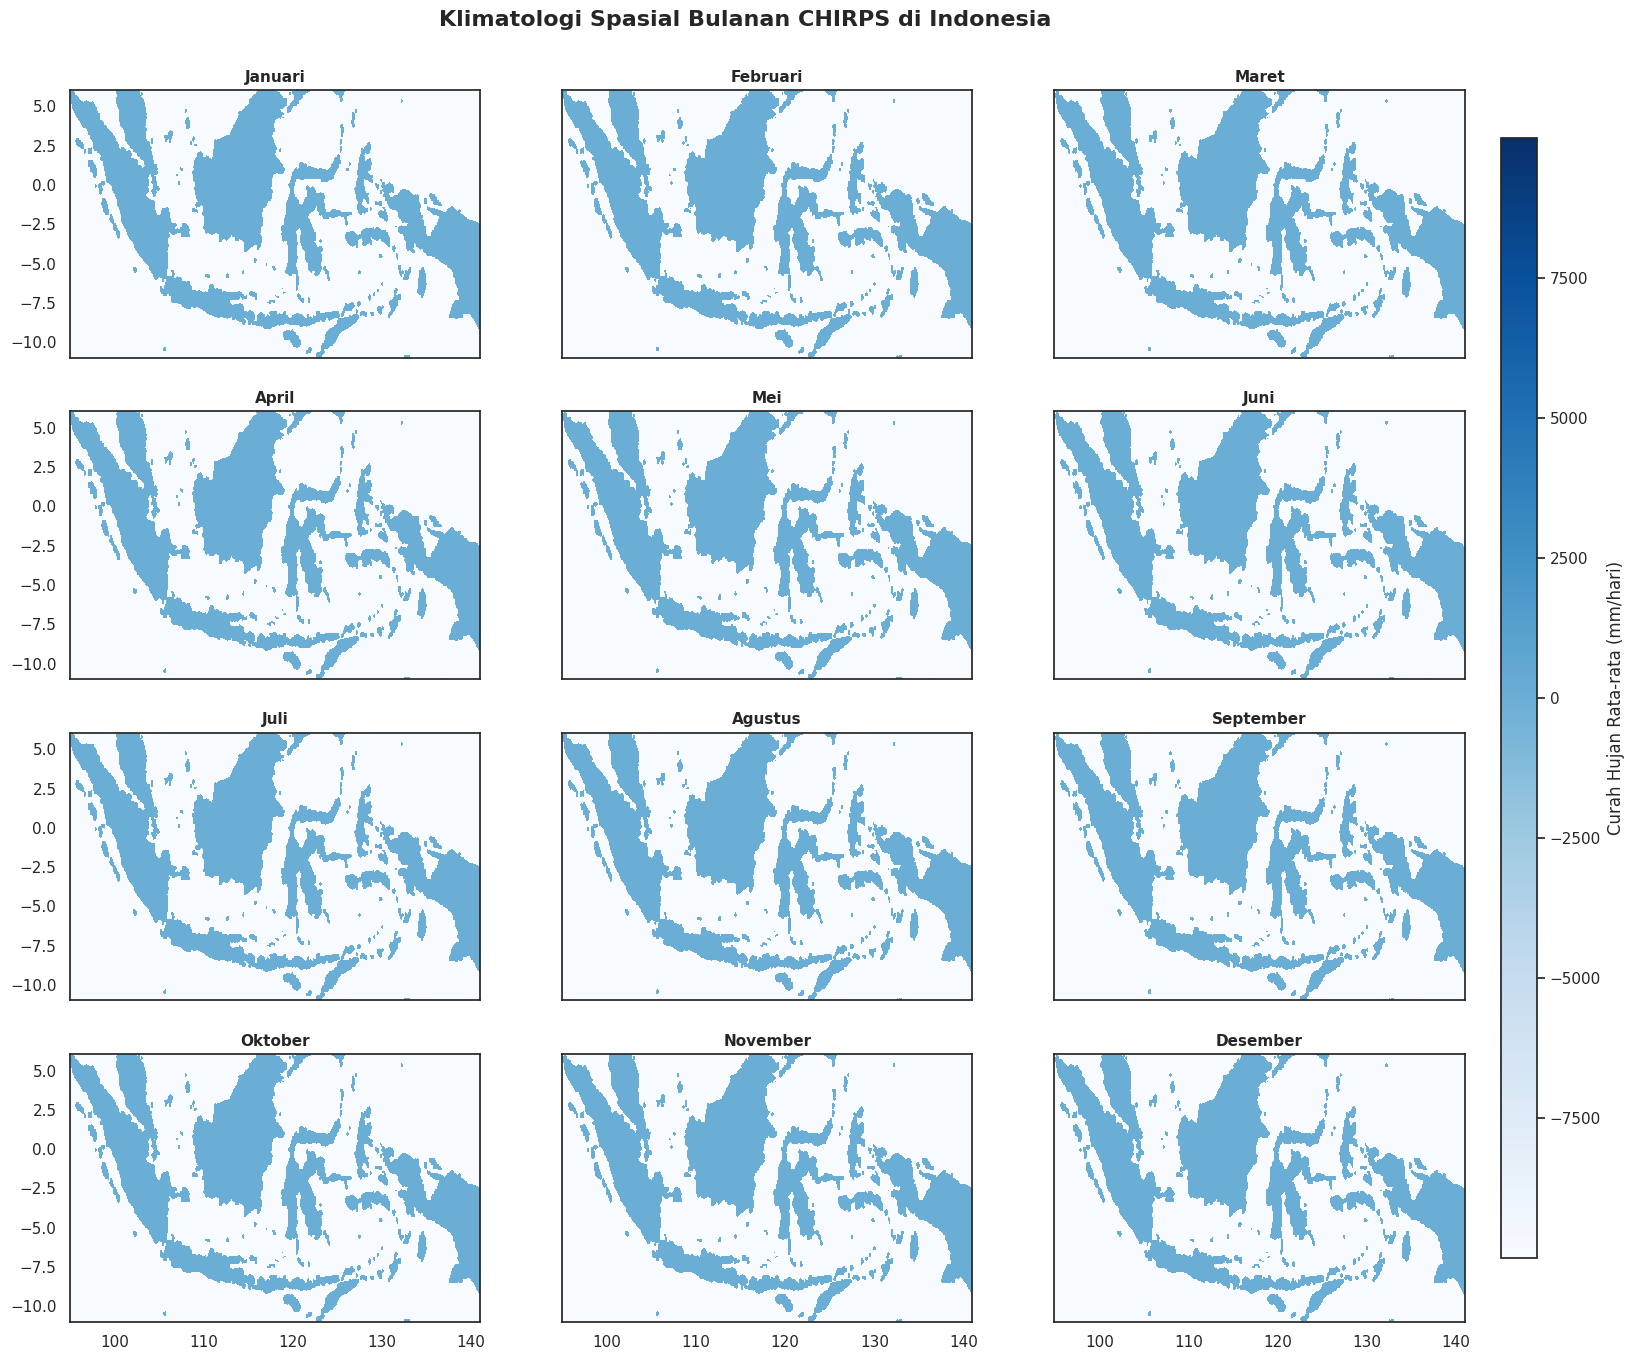

In [6]:
monthly_means = ds['precipitation'].groupby('time.month').mean(dim='time')
month_names = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 
               'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']

fig, axes = plt.subplots(4, 3, figsize=(18, 16), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(12):
    ax = axes[i]
    m_data = monthly_means.sel(month=i+1)
    im = m_data.plot(ax=ax, add_colorbar=False, cmap='Blues')
    if gdf_indo is not None:
        gdf_indo.boundary.plot(ax=ax, color='black', linewidth=0.4, alpha=0.6)
    ax.set_title(f"{month_names[i]}", fontsize=11, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("")

# Tambahkan Colorbar bersama di kanan
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Curah Hujan Rata-rata (mm/hari)')

fig.suptitle("Klimatologi Spasial Bulanan CHIRPS di Indonesia", fontsize=16, fontweight='bold', y=0.93)
plt.show()

## 6. Indeks Hujan Ekstrem Spasial (RX1day & Hari Hujan Lebat)
Menghitung kejadian hujan paling ekstrem (RX1day) dan frekuensi hari hujan lebat (> 10 mm/hari) pada setiap piksel grid.

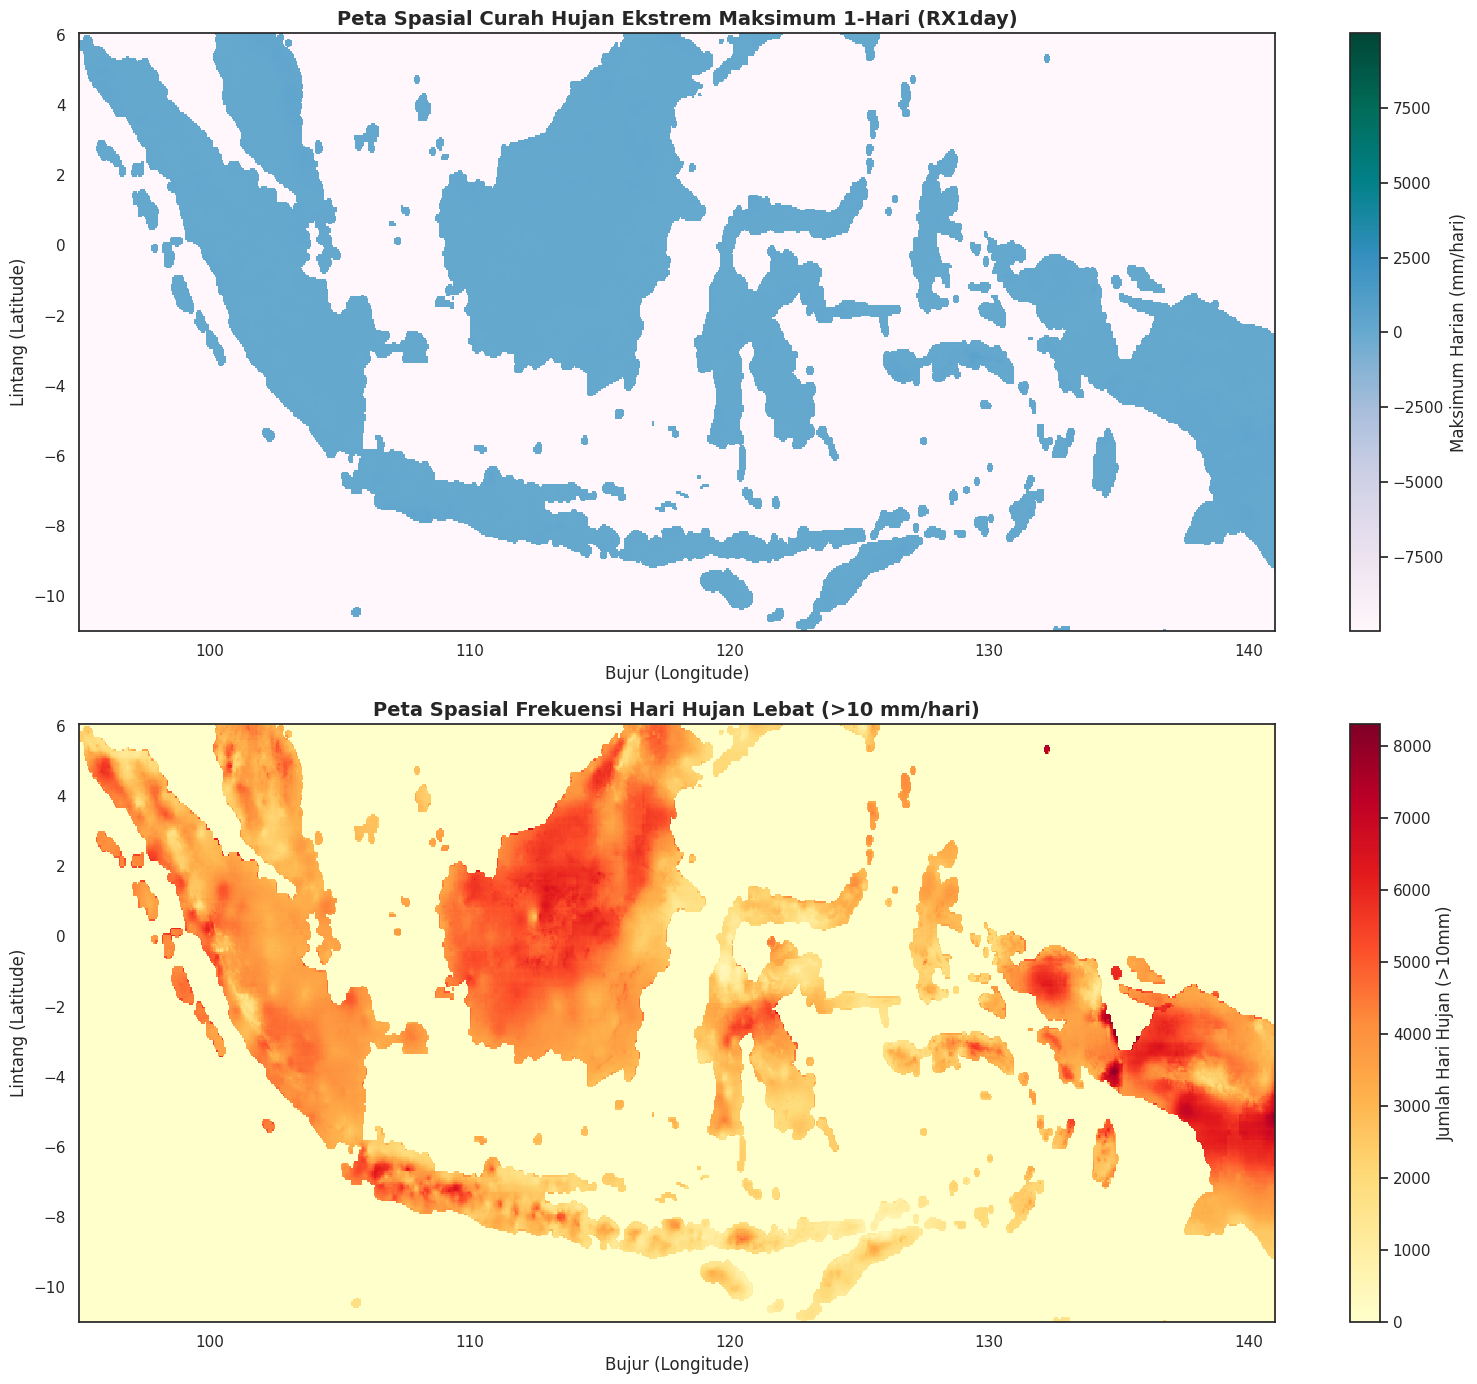

In [7]:
# RX1day: Curah hujan harian maksimum
rx1day = ds['precipitation'].max(dim='time')

# Hari Hujan Lebat (> 10 mm/hari)
heavy_rain_days = (ds['precipitation'] > 10).sum(dim='time')

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# Plot RX1day
rx1day.plot(ax=axes[0], cmap='PuBuGn', cbar_kwargs={'label': 'Maksimum Harian (mm/hari)'})
if gdf_indo is not None:
    gdf_indo.boundary.plot(ax=axes[0], color='black', linewidth=0.6)
axes[0].set_title("Peta Spasial Curah Hujan Ekstrem Maksimum 1-Hari (RX1day)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Bujur (Longitude)")
axes[0].set_ylabel("Lintang (Latitude)")

# Plot Hari Hujan Lebat
heavy_rain_days.plot(ax=axes[1], cmap='YlOrRd', cbar_kwargs={'label': 'Jumlah Hari Hujan (>10mm)'})
if gdf_indo is not None:
    gdf_indo.boundary.plot(ax=axes[1], color='black', linewidth=0.6)
axes[1].set_title("Peta Spasial Frekuensi Hari Hujan Lebat (>10 mm/hari)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Bujur (Longitude)")
axes[1].set_ylabel("Lintang (Latitude)")

plt.tight_layout()
plt.show()

## 7. Peta Persentase Anomali Spasial Curah Hujan
Menghitung deviasi persentase curah hujan terhadap rerata spasial.

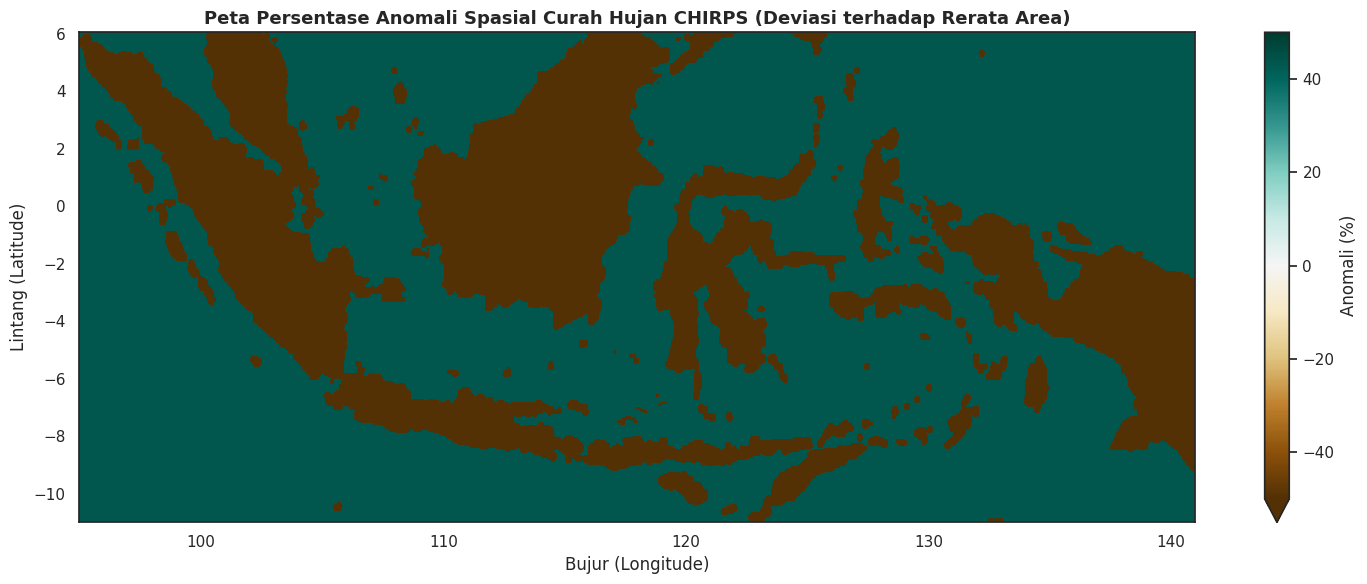

In [8]:
# Hitung rata-rata keseluruhan
overall_mean = spatial_mean.mean()
anomaly_pct = ((spatial_mean - overall_mean) / overall_mean) * 100

plt.figure(figsize=(15, 6))
anomaly_pct.plot(cmap='BrBG', vmin=-50, vmax=50, cbar_kwargs={'label': 'Anomali (%)'})
if gdf_indo is not None:
    gdf_indo.boundary.plot(color='black', linewidth=0.6)
plt.title("Peta Persentase Anomali Spasial Curah Hujan CHIRPS (Deviasi terhadap Rerata Area)", fontsize=13, fontweight='bold')
plt.xlabel("Bujur (Longitude)")
plt.ylabel("Lintang (Latitude)")
plt.tight_layout()
plt.show()